# Final results — PD

Every trained CreditPFN checkpoint, every classical baseline,
and every untuned-TabPFN reference, scored on every held-out
test dataset with 5-fold cross-validation. The visualisations
here are the canonical "how did we do" view — used both for
thesis figures and for picking the headline checkpoint to
report.

## Where the data comes from

`scripts/eval_pipeline.py` writes one wide-format CSV per
(method × run × timestamp) under
`output/results/<TRACK>/<method-dirname>/...csv`.

Each row is one `(model × test_dataset × fold)` tuple with all
metric columns side-by-side:

* **PD (classification)** — `roc_auc, log_loss, pr_auc,
  optimal_threshold, f1, accuracy, precision, recall`.
* **LGD (regression)** — `rmse, mae, r2, neg_nll`.

Method directory names encode the architecture, and
`src/utils/eval_viz._decode_method_dirname` parses them into
structured `(source, base_short, lr, use_lora)` fields. The
human-readable label used in legends is built by
`human_method_name()`.

All loaders and plots live in `src/utils/eval_viz.py`;
this notebook only calls them.

## Direction of improvement

Higher-is-better metrics: `roc_auc`, `pr_auc`, `f1`, `accuracy`,
`precision`, `recall`, `r2`, `neg_nll`.
Lower-is-better: `rmse`, `mae`, `log_loss`. Every aggregation /
ranking helper is direction-aware.

## Sections

1. Setup and what's on disk
2. Headline leaderboard
3. Per-dataset performance
4. Pairwise comparisons (win-rate matrix, scatter)
5. Trained vs untuned TabPFN (the Real-TabPFN-style "did it help?" plot)
6. Stability and calibration
7. Time vs accuracy
8. Failures

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
# pyproject.toml, not a module path: src/visualize/ used to be
# src/utils/ and this loop then walked past the repo root.
while not (REPO / 'pyproject.toml').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# `display` is an IPython builtin. src/utils/run_notebooks.py executes this file as
# a plain script to rebuild All_Results.md, where it is not — so import it.
from IPython.display import display

import pandas as pd
from src.visualize.figures import FigureSaver
from src.visualize import style
from src.visualize.eval_viz import (
    load_eval_results, available_methods, available_datasets,
    primary_metric, eval_leaderboard, failed_pairs,
    aggregate_per_method, aggregate_per_method_per_dataset, winrate_matrix,
    plot_leaderboard, plot_metric_boxplot, plot_per_dataset_heatmap,
    plot_winrate_matrix, plot_method_vs_method_scatter,
    plot_trained_vs_untuned, plot_baselines_vs_tabpfn,
    plot_fold_stability, plot_metric_correlation,
    plot_threshold_distribution, plot_top_method_per_dataset,
    plot_dataset_difficulty, plot_time_vs_metric,
)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
TRACK = 'pd'    # this notebook is fixed to the PD track
sink = FigureSaver('2.0. final_results_pd')

# One style for every figure in this project.
style.apply()


## 1 · What's on disk

`load_eval_results` pools every CSV under
`output/results/<TRACK>/**/*.csv` and tags each row with
`(source, base_short, lr, use_lora, method_name, source_file)`
derived from the parent directory name.

If the tables below are empty, the eval pipeline hasn't produced
any CSVs yet for this track — the notebook will still render but
every plot will show a *(no data)* stub.

In [2]:
print(f'Primary metric for track={TRACK}: {primary_metric(TRACK)}')
print(f'Methods on disk : {len(available_methods(TRACK))}')
print(f'Test datasets   : {len(available_datasets(TRACK))}')
available_methods(TRACK)

Primary metric for track=pd: roc_auc
Methods on disk : 6
Test datasets   : 5


['catboost',
 'logreg',
 'trained (v3-default) lr=3e-07',
 'untuned (v2.6-default)',
 'untuned (v3-default)',
 'xgboost']

In [3]:
raw = load_eval_results(TRACK)
print(f'rows: {len(raw)}')
if not raw.empty:
    display(raw.head(10))

rows: 145


,track,task_type,model_name,model_source,model_path,test_dataset_id,fold_idx,n_train_rows,n_val_rows,n_test_rows,roc_auc,log_loss,pr_auc,brier_score,ece,optimal_threshold,f1,accuracy,precision,recall,...,median_ae,mape,r2,explained_variance,pearson_r,spearman_r,neg_nll,elapsed_sec,timestamp,status,error,method_dirname,source,base_short,lr,use_lora,full_pass,family,source_file,method_name
0,pd,classification,catboost,baseline,NaN,0002.taiwan_creditcard,0,19200,4800,6000,0.792251,0.423187,0.560088,0.132811,0.014894,0.242743,0.562329,0.787000,0.515704,0.618223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.844968,20260602_142157,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142157__task5_d...,catboost
1,pd,classification,catboost,baseline,NaN,0002.taiwan_creditcard,1,19200,4800,6000,0.778370,0.431453,0.552214,0.135493,0.010873,0.258704,0.543983,0.784000,0.510231,0.582517,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.625765,20260602_142157,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142157__task5_d...,catboost
2,pd,classification,catboost,baseline,NaN,0002.taiwan_creditcard,2,19200,4800,6000,0.780942,0.431231,0.551844,0.135368,0.011643,0.267303,0.545520,0.788667,0.520164,0.573474,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.847012,20260602_142157,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142157__task5_d...,catboost
3,pd,classification,catboost,baseline,NaN,0002.taiwan_creditcard,3,19200,4800,6000,0.781573,0.424779,0.564761,0.132278,0.007815,0.264024,0.560286,0.795167,0.533379,0.590053,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.073284,20260602_142157,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142157__task5_d...,catboost
4,pd,classification,catboost,baseline,NaN,0002.taiwan_creditcard,4,19200,4800,6000,0.778254,0.428859,0.564512,0.134610,0.013417,0.257053,0.534695,0.779833,0.501984,0.571967,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.629977,20260602_142157,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142157__task5_d...,catboost
5,pd,classification,catboost,baseline,NaN,0005.myhom,0,4480,1120,1400,0.596943,0.660273,0.476021,0.233985,0.006370,0.330201,0.584101,0.484286,0.431122,0.905357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.821640,20260602_142750,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142750__task6_d...,catboost
6,pd,classification,catboost,baseline,NaN,0005.myhom,1,4480,1120,1400,0.571264,0.666869,0.455400,0.237073,0.021580,0.395015,0.543360,0.518571,0.437773,0.716071,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.742087,20260602_142750,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142750__task6_d...,catboost
7,pd,classification,catboost,baseline,NaN,0005.myhom,2,4480,1120,1400,0.588636,0.665498,0.476860,0.235872,0.028252,0.326377,0.570896,0.507143,0.437977,0.819643,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.078409,20260602_142750,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142750__task6_d...,catboost
8,pd,classification,catboost,baseline,NaN,0005.myhom,3,4480,1120,1400,0.575101,0.670626,0.448737,0.238533,0.046648,0.277125,0.566143,0.447143,0.412582,0.901786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.771566,20260602_142750,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142750__task6_d...,catboost
9,pd,classification,catboost,baseline,NaN,0005.myhom,4,4480,1120,1400,0.595092,0.659943,0.495407,0.233673,0.015510,0.291374,0.570125,0.461429,0.418760,0.892857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.712417,20260602_142750,OK,NaN,catboost,baseline,catboost,NaN,False,False,classical,PD\catboost\creditpfn_20260602_142750__task6_d...,catboost


## 2 · Headline leaderboard

Mean ± std of the primary metric (`roc_auc` for PD, `rmse` for
LGD) pooled over all `(dataset × fold)` rows of each method.
Sorted direction-aware so the best method is always at the top.

In [4]:
eval_leaderboard(TRACK)

,method_name,mean,median,std,count
0,untuned (v3-default),0.762165,0.785984,0.126170,25
1,untuned (v2.6-default),0.752887,0.775812,0.120639,25
2,xgboost,0.749144,0.777295,0.126639,25
3,catboost,0.748642,0.770427,0.124628,25
4,logreg,0.702275,0.721594,0.092945,25


WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/01_leaderboard.pdf')

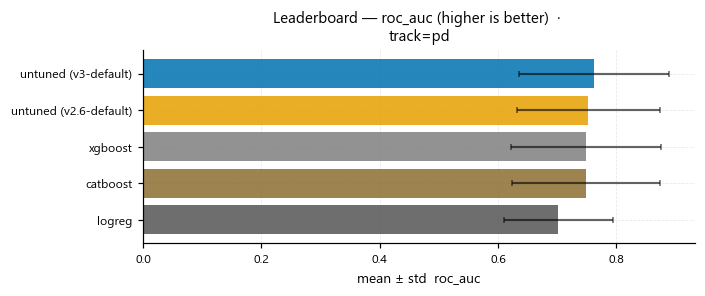

In [5]:
sink.save(plot_leaderboard(TRACK), 'leaderboard',
          caption="Mean primary metric per method over all held-out datasets and cross-validation folds, sorted, with one standard deviation as error bars.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/02_metric_boxplot.pdf')

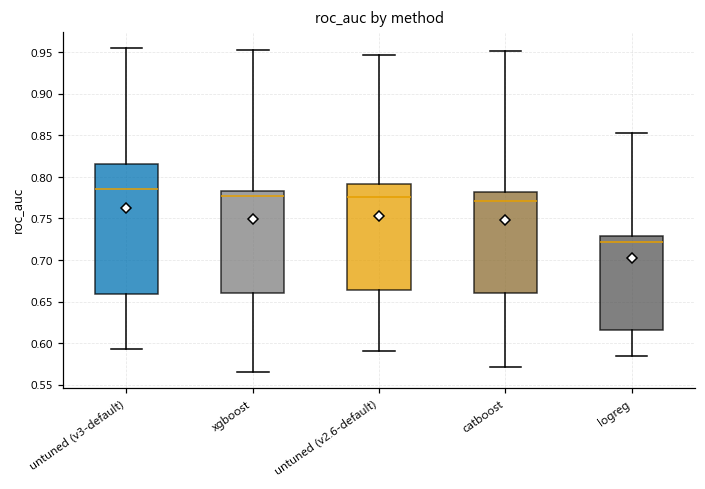

In [6]:
sink.save(plot_metric_boxplot(TRACK), 'metric_boxplot',
          caption="Distribution of the primary metric per method over all (dataset, fold) cells.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/03_baselines_vs_tabpfn.pdf')

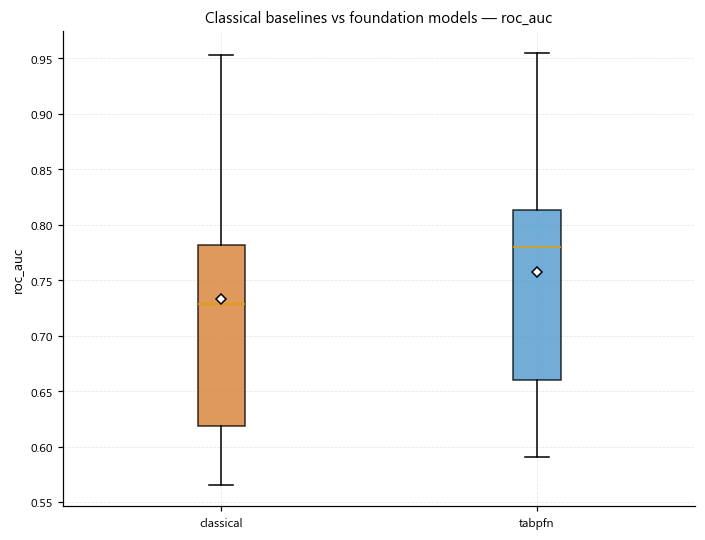

In [7]:
sink.save(plot_baselines_vs_tabpfn(TRACK), 'baselines_vs_tabpfn',
          caption="Distribution of the primary metric for the classical baselines and for the foundation-model family, side by side, over all (dataset, fold) cells.")

## 3 · Per-dataset performance

Each row of the heatmap is a method, each column a held-out test
dataset, each cell the mean of the primary metric over the
5-fold CV. The bottom plot "who wins on which dataset?" colours
each dataset by its best-performing method — a fast diagnostic
for finding datasets where the trained checkpoint isn't paying
off.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/04_per_dataset_heatmap.pdf')

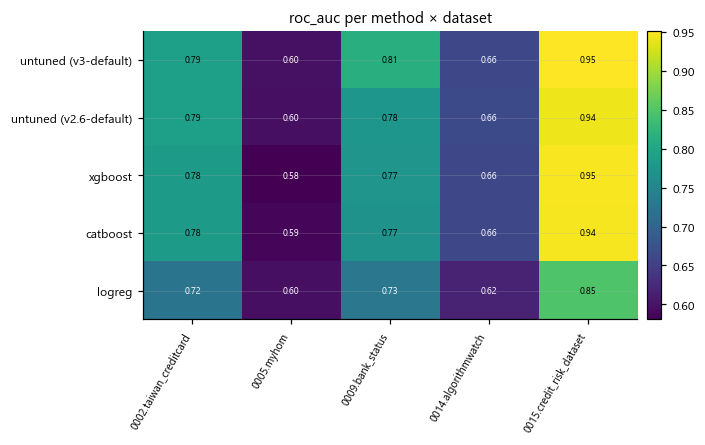

In [8]:
sink.save(plot_per_dataset_heatmap(TRACK), 'per_dataset_heatmap',
          caption="Mean primary metric for every method on every held-out dataset, averaged over folds.")

In [9]:
aggregate_per_method_per_dataset(TRACK).round(3)

test_dataset_id,0002.taiwan_creditcard,0005.myhom,0009.bank_status,0014.algorithmwatch,0015.credit_risk_dataset
method_name,,,,,
catboost,0.782,0.585,0.770,0.661,0.945
logreg,0.723,0.595,0.728,0.616,0.849
untuned (v2.6-default),0.789,0.595,0.775,0.664,0.941
untuned (v3-default),0.789,0.597,0.813,0.661,0.951
xgboost,0.783,0.581,0.774,0.662,0.947


WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/05_top_method_per_dataset.pdf')

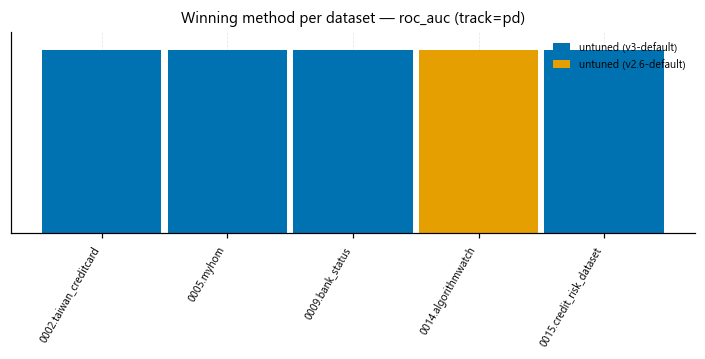

In [10]:
sink.save(plot_top_method_per_dataset(TRACK), 'top_method_per_dataset',
          caption="The best-scoring method on each held-out dataset, one bar per dataset.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/06_dataset_difficulty.pdf')

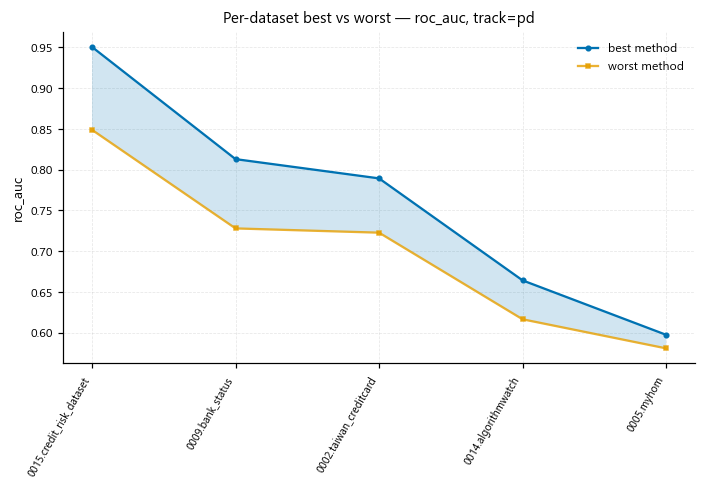

In [11]:
sink.save(plot_dataset_difficulty(TRACK), 'dataset_difficulty',
          caption="Best and worst primary metric achieved on each held-out dataset, ordered by the best score.")

## 4 · Pairwise comparisons

The **win-rate matrix** counts, for each ordered pair of methods
(`row` vs `column`), the fraction of test datasets where `row`
beat `column` (direction-aware). It is the same plot type as
Fig. 3 of the [TabPFN-3 technical report](../tfm-library/papers/2026/05_Grinsztajn_et_al._TabPFN_3_Technical_Report.pdf) —
a fast way to see which method dominates which.

The **method-vs-method scatter** lets you pick any two methods
and view their per-dataset scores side by side; points above
the y = x line favour the y-axis method.

In [12]:
winrate_matrix(TRACK).round(2)

,catboost,logreg,untuned (v2.6-default),untuned (v3-default),xgboost
catboost,NaN,0.8,0.2,0.2,0.2
logreg,0.2,NaN,0.2,0.0,0.2
untuned (v2.6-default),0.8,0.8,NaN,0.2,0.8
untuned (v3-default),0.8,1.0,0.8,NaN,0.8
xgboost,0.8,0.8,0.2,0.2,NaN


WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/07_winrate_matrix.pdf')

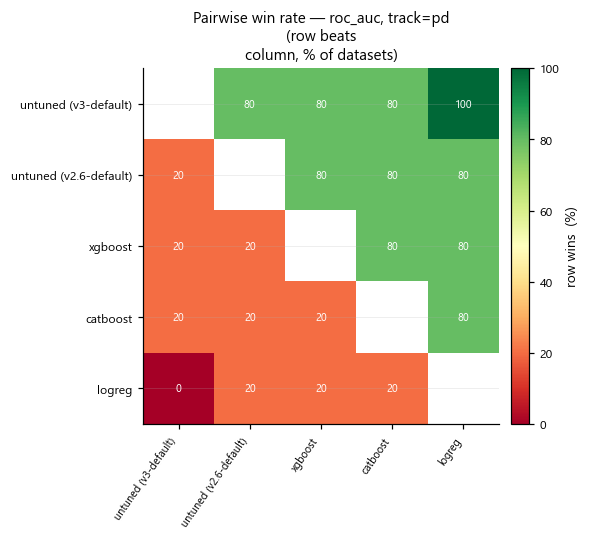

In [13]:
sink.save(plot_winrate_matrix(TRACK), 'winrate_matrix',
          caption="Pairwise win rate: the fraction of shared (dataset, fold) cells on which the row method beat the column method.")

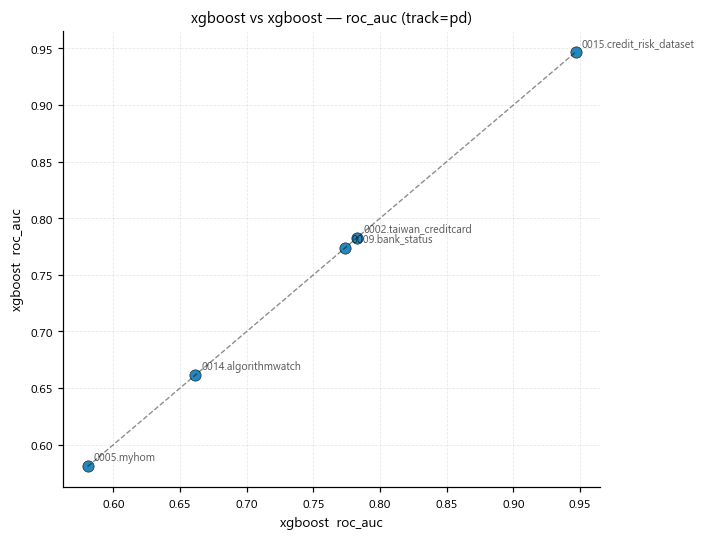

In [14]:
# Pick any two methods from `available_methods(TRACK)`. The defaults
# below compare XGBoost (the strongest classical) against the best
# trained CreditPFN (whichever currently leads the leaderboard).
methods = available_methods(TRACK)
if len(methods) >= 2:
    classical_pick = next((m for m in methods if m == 'xgboost'), methods[0])
    creditpfn_pick = next((m for m in eval_leaderboard(TRACK)['method_name'].tolist()
                           if m.startswith('trained (')), methods[-1])
    _ = plot_method_vs_method_scatter(TRACK, classical_pick, creditpfn_pick)
else:
    print('Need at least two methods on disk to draw a scatter.')

## 5 · Trained vs untuned TabPFN

The **Real-TabPFN** [Garg 2025](../tfm-library/papers/2025/07_Garg_et_al._Real_TabPFN_Improving_Tabular_Foundation_Models_via_Continued_Pre_training_With_Real_World_Data.pdf)
headline figure: for each `(test_dataset, trained_checkpoint)`,
scatter the trained metric against the matching untuned TabPFN
of the **same architecture**. Points above the y = x line are
datasets where continued pretraining actually helped.

Points are coloured by base architecture — so you can spot
*"v3 helps but v2.5 doesn't"* or vice versa.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/08_trained_vs_untuned.pdf')

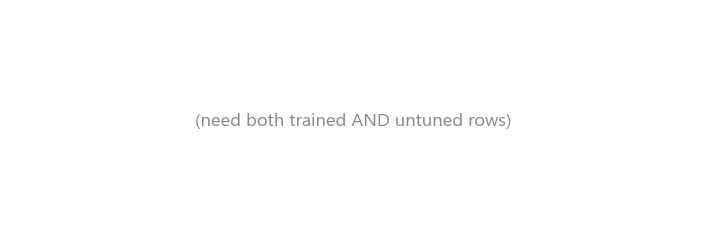

In [15]:
sink.save(plot_trained_vs_untuned(TRACK), 'trained_vs_untuned',
          caption="Primary metric of each trained checkpoint against its own untuned base on the same dataset. Points above the diagonal are datasets where continued pretraining helped.")

## 6 · Stability and calibration

* **Fold stability** — std of the primary metric across the 5
  outer folds for each `(method, dataset)`. A method whose box
  sits high is reporting high variance — a worse choice for
  production even if its mean looks good.
* **Metric correlation** — pairwise correlation between every
  metric column on disk. Useful to know whether picking the
  ROC-AUC winner is robust to switching to PR-AUC, or whether
  there's a calibration / discrimination trade-off lurking.
* **Threshold distribution** *(PD only)* — F1-optimal threshold
  per method. A method whose threshold drifts far from 0.5
  produces poorly-calibrated probabilities.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/09_fold_stability.pdf')

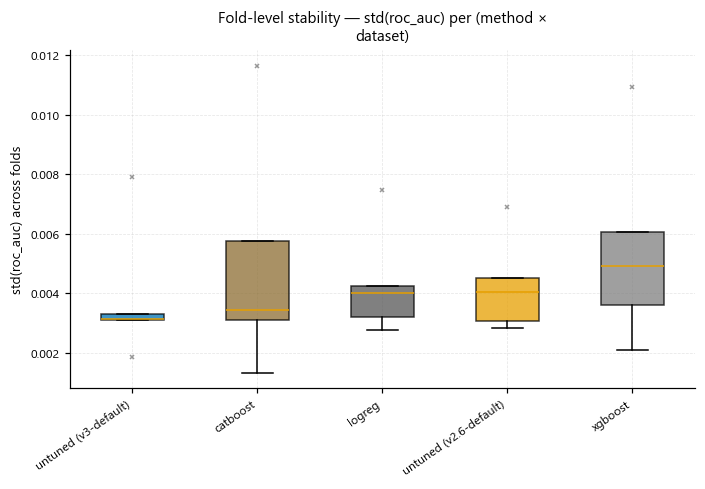

In [16]:
sink.save(plot_fold_stability(TRACK), 'fold_stability',
          caption="Distribution of the across-fold standard deviation of the primary metric, per method — how repeatable a score is.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/10_metric_correlation.pdf')

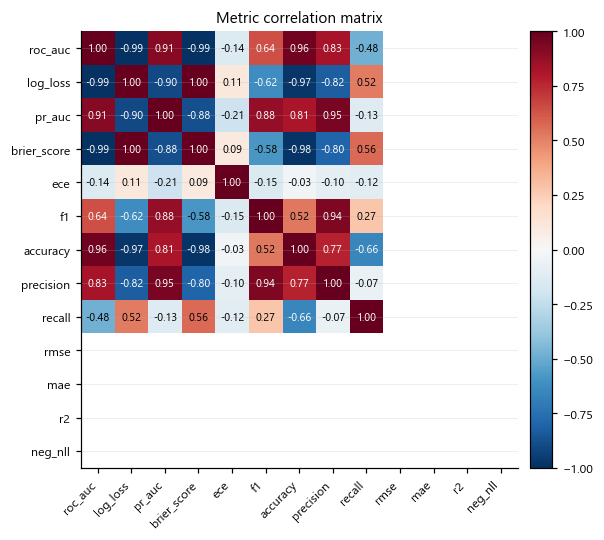

In [17]:
sink.save(plot_metric_correlation(TRACK), 'metric_correlation',
          caption="Correlation between the recorded metrics over all scored cells.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/11_threshold_distribution.pdf')

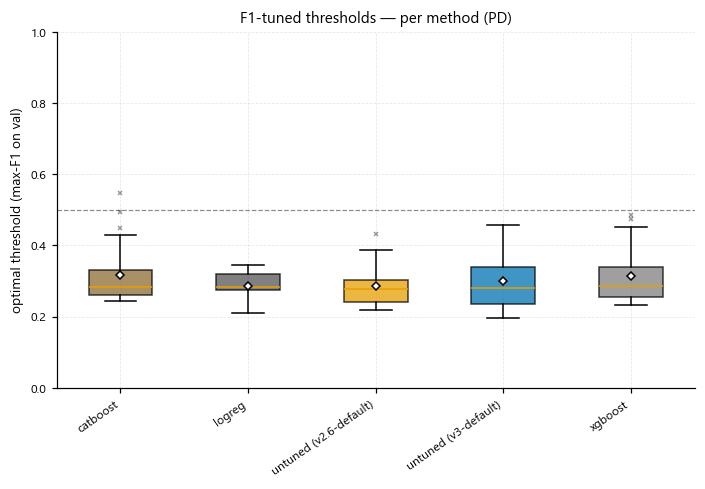

In [18]:
sink.save(plot_threshold_distribution(TRACK), 'threshold_distribution',
          caption="Distribution of the F1-tuned decision thresholds per method, over all (dataset, fold) cells.")

## 7 · Time vs accuracy

Per-fold elapsed seconds against the primary metric. Pareto-dominated
points are methods that another method matches in less time.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/12_time_vs_metric.pdf')

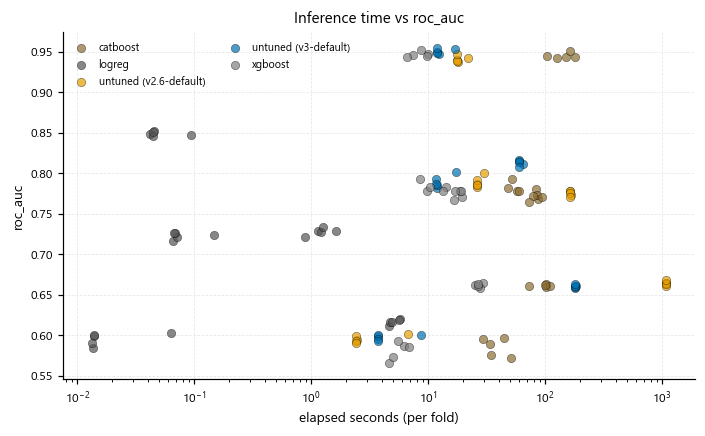

In [19]:
sink.save(plot_time_vs_metric(TRACK), 'time_vs_metric',
          caption="Per-row inference time against primary metric, one point per (method, dataset), coloured by method.")

## 8 · Failures

Any `(method, dataset, fold)` triple with status ≠ OK. Most often
an HPO timeout (Optuna budget exhausted) or a CUDA OOM on a wide
dataset. Investigate the `error` column before treating an empty
row in the heatmap as missing data.

In [20]:
fails = failed_pairs(TRACK)
if fails.empty:
    print('No failed (method × dataset × fold) rows. ✔')
else:
    display(fails)

,method_name,test_dataset_id,fold_idx,status,error,elapsed_sec,source_file
0,trained (v3-default) lr=3e-07,0002.taiwan_creditcard,0,FAIL,RuntimeError: Error(s) in loading state_dict f...,4.901147,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
1,trained (v3-default) lr=3e-07,0002.taiwan_creditcard,1,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.046214,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
2,trained (v3-default) lr=3e-07,0002.taiwan_creditcard,2,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.044298,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
3,trained (v3-default) lr=3e-07,0002.taiwan_creditcard,3,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.044285,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
4,trained (v3-default) lr=3e-07,0002.taiwan_creditcard,4,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.043235,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
5,trained (v3-default) lr=3e-07,0005.myhom,0,FAIL,RuntimeError: Error(s) in loading state_dict f...,4.009707,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
6,trained (v3-default) lr=3e-07,0005.myhom,1,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.044157,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
7,trained (v3-default) lr=3e-07,0005.myhom,2,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.045295,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
8,trained (v3-default) lr=3e-07,0005.myhom,3,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.044565,PD\tabpfn-trained__v3-default__lr3e-07\creditp...
9,trained (v3-default) lr=3e-07,0005.myhom,4,FAIL,RuntimeError: Error(s) in loading state_dict f...,0.043498,PD\tabpfn-trained__v3-default__lr3e-07\creditp...


## 9. Figures for the paper

The set below is what a manuscript about this project needs, and is kept deliberately
small; everything above this point is diagnostic. Each one answers a question the
literature says a continued-pretraining result must answer:

| figure | question | precedent |
|---|---|---|
| paired effect | did continued pretraining help, against each model's **own** base? | every CPT paper |
| gain vs base quality | does it help most where the base was weakest? | our mechanism |
| mean rank | which model wins across datasets, scale-free? | Hollmann 2025, Purucker 2026 |
| calibration shift | did adaptation damage the probabilities? | Tanna 2026; regulatory relevance |
| regime | where does it help — as a function of dataset size? | Purucker 2026 (ρ = +0.60) |
| honest selection | how much does best-on-test overstate? | winner's curse |
| forgetting | did adaptation destroy what the prior knew? | Kolberg 2026 (ρ = 0.9935) |

All of them are **paired**: a trained checkpoint is compared to its own untuned base on
the same dataset. An unpaired mean over models scored on different dataset subsets is
dominated by which datasets each model happened to get — which is exactly what a partial
eval produces.

In [21]:
from src.visualize import paper_figures as pf
from src.utils.paths import manifests_dir

METRIC = primary_metric(TRACK)
# Dataset properties for the regime figure: rows, features, imbalance.
corpus_manifest = pd.read_csv(manifests_dir() / f'manifest_{TRACK}.csv')
print(f'paper figures: metric={METRIC}, {len(corpus_manifest)} datasets in the manifest')


paper figures: metric=roc_auc, 17 datasets in the manifest


WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/13_paper_paired_effect.pdf')

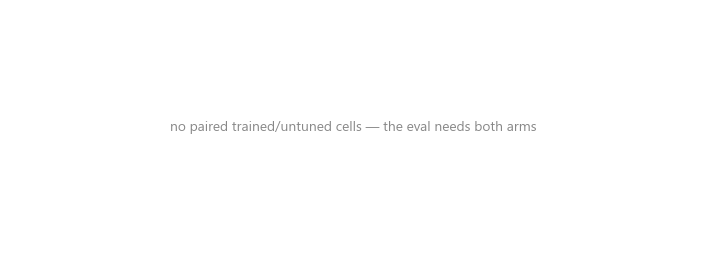

In [22]:
sink.save(pf.plot_paired_delta(raw, METRIC), 'paper_paired_effect',
          caption="Change in roc_auc from continued pretraining, each trained checkpoint against its own untuned base on the same dataset. One point per (checkpoint, dataset); horizontal bars mark the per-base mean; the line at zero is no change.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/14_paper_gain_vs_base.pdf')

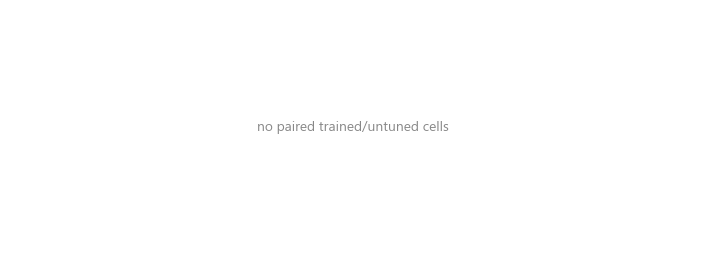

In [23]:
sink.save(pf.plot_gain_vs_base(raw, METRIC), 'paper_gain_vs_base',
          caption="Change in roc_auc against the untuned base's score on the same dataset, one point per (checkpoint, dataset), coloured by base checkpoint. The line is an ordinary least-squares fit over all points.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/15_paper_mean_rank.pdf')

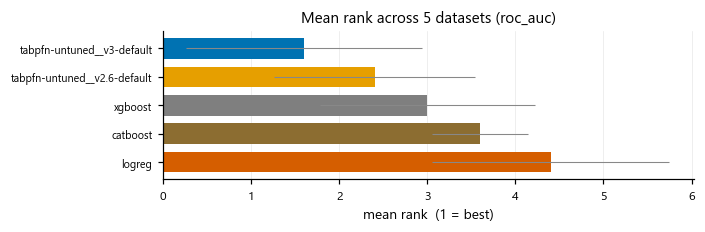

In [24]:
sink.save(pf.plot_mean_rank(raw, METRIC, label_map=None),
          'paper_mean_rank',
          caption="Mean rank of each method across the held-out datasets scored by every method, computed per dataset and then averaged; bars show one standard deviation. Rank 1 is best.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/16_paper_calibration.pdf')

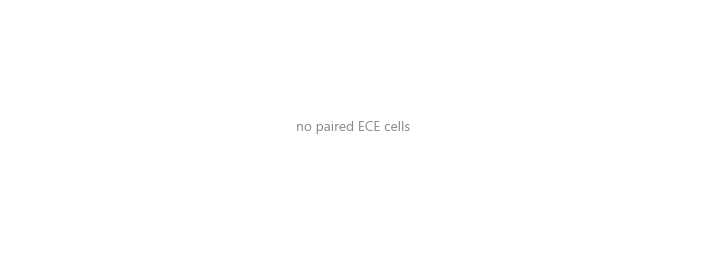

In [25]:
sink.save(pf.plot_calibration_shift(raw), 'paper_calibration',
          caption="Expected calibration error of each trained checkpoint against its own untuned base on the same dataset. Points above the diagonal are worse calibrated after continued pretraining.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/17_paper_regime.pdf')

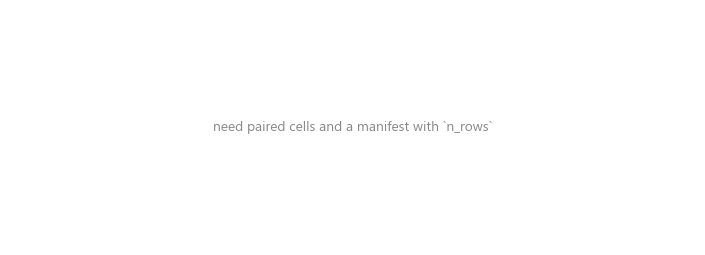

In [26]:
sink.save(pf.plot_regime_effect(raw, corpus_manifest, METRIC, 'n_rows'), 'paper_regime',
          caption="Change in roc_auc against dataset size, one point per (checkpoint, dataset), log x axis. Spearman correlation and its p-value are computed over all points shown.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/18_paper_selection.pdf')

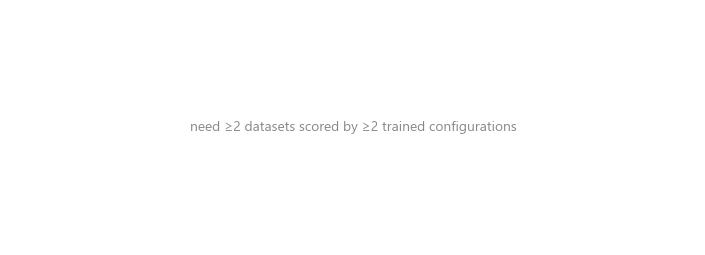

In [27]:
sink.save(pf.plot_selection_honesty(raw, METRIC), 'paper_selection',
          caption="Per dataset, the roc_auc of the configuration selected on the other datasets only (leave-one-dataset-out) against the best roc_auc achievable on that dataset. The gap is the optimism of selecting on the test set.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/2.0. final_results_pd/19_paper_forgetting.pdf')

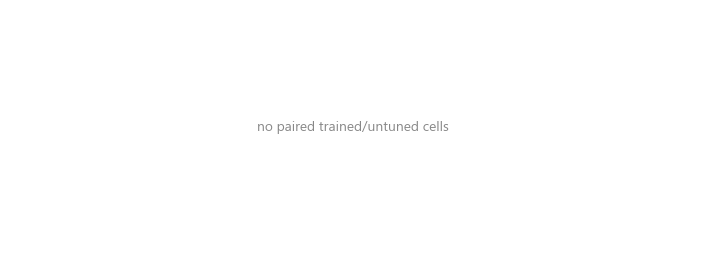

In [28]:
sink.save(pf.plot_forgetting(raw, METRIC), 'paper_forgetting',
          caption="Trained against untuned roc_auc for every (checkpoint, dataset) pair, with the identity line. Spearman correlation over all pairs quantifies how far adaptation reordered the model's behaviour.")

In [29]:
fails = failed_pairs(TRACK)
print(f'## 2.0 final results ({TRACK})')
print(f'failed (method x dataset x fold) rows: {len(fails)}')
if len(fails):
    print(fails.to_string())
print()
print(sink.summary())


## 2.0 final results (pd)
failed (method x dataset x fold) rows: 20
                      method_name         test_dataset_id  fold_idx status                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          